In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [50]:
df = pd.read_csv('Algerian_forest_fires_dataset_cleaned.csv')

In [51]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0.0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0.0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0.0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0.0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0.0


In [52]:
df.drop(['day','month','year'],axis=1,inplace=True)

In [53]:
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0.0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0.0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0.0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0.0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0.0


In [54]:
df['Classes'].value_counts()

,count
Classes,
fire,131
not fire,101
fire,4
fire,2
not fire,2
not fire,1
not fire,1
not fire,1


In [55]:
df['Classes'] = np.where(df['Classes'].str.contains("not fire"),0,1)

In [56]:
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0.0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0.0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0.0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0.0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0.0


In [57]:
df.tail()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,region
238,30,65,14,0.0,85.4,16.0,44.5,4.5,16.9,6.5,1,1.0
239,28,87,15,4.4,41.1,6.5,8.0,0.1,6.2,0.0,0,1.0
240,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0.2,0,1.0
241,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0.7,0,1.0
242,24,64,15,0.2,67.3,3.8,16.5,1.2,4.8,0.5,0,1.0


In [58]:
df['Classes'].value_counts()

,count
Classes,
1,137
0,106


In [59]:
X = df.drop('FWI',axis=1)
Y = df['FWI']

In [60]:
X.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0,0.0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0,0.0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0,0.0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0,0.0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0,0.0


In [61]:
Y.head()

,FWI
0,0.5
1,0.4
2,0.1
3,0.0
4,0.5


In [62]:
# train test split
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=0)

In [63]:
X_train.shape,X_test.shape

((194, 11), (49, 11))

In [64]:
Y_train.shape,Y_test.shape

((194,), (49,))

In [65]:
X_train.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,region
Temperature,1.000000,-0.666832,-0.363524,-0.353372,0.684186,0.485272,0.344520,0.610784,0.447509,0.497727,0.316034
RH,-0.666832,1.000000,0.268542,0.252659,-0.639914,-0.400913,-0.206873,-0.700103,-0.340127,-0.431097,-0.442337
Ws,-0.363524,0.268542,1.000000,0.219551,-0.238520,-0.026332,0.057709,-0.025648,0.008292,-0.106459,-0.188898
Rain,-0.353372,0.252659,0.219551,1.000000,-0.588079,-0.300879,-0.306149,-0.351447,-0.310650,-0.377688,-0.076930
FFMC,0.684186,-0.639914,-0.238520,-0.588079,1.000000,0.610152,0.511148,0.736174,0.596990,0.765968,0.275874
DMC,0.485272,-0.400913,-0.026332,-0.300879,0.610152,1.000000,0.884202,0.673975,0.982542,0.592269,0.194039
DC,0.344520,-0.206873,0.057709,-0.306149,0.511148,0.884202,1.000000,0.489671,0.945585,0.513694,-0.060157
ISI,0.610784,-0.700103,-0.025648,-0.351447,0.736174,0.673975,0.489671,1.000000,0.632169,0.732387,0.313642
BUI,0.447509,-0.340127,0.008292,-0.310650,0.596990,0.982542,0.945585,0.632169,1.000000,0.593063,0.094501
Classes,0.497727,-0.431097,-0.106459,-0.377688,0.765968,0.592269,0.513694,0.732387,0.593063,1.000000,0.209882


<Axes: >

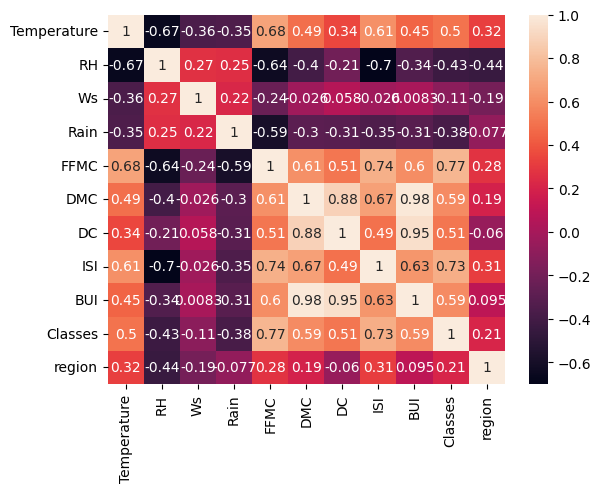

In [66]:
plt.Figure(figsize=(15,6))
sns.heatmap(X_train.corr(),annot=True)

In [67]:
def correlation(dataset,threshold):
  col_corr = set()
  corr_matrix = dataset.corr()
  for i in range(len(corr_matrix.columns)):
    for j in range(i):
      if abs(corr_matrix.iloc[i,j]) > threshold:
        columname = corr_matrix.columns[i]
        col_corr.add(columname)
  return col_corr

In [68]:
corr_features=correlation(X_train,0.85)

In [69]:
corr_features

{'BUI', 'DC'}

In [70]:
X_train.drop(corr_features,axis=1,inplace=True)
X_test.drop(corr_features,axis=1,inplace=True)
X_train.shape,X_test.shape

((194, 9), (49, 9))

## Feature scaling

In [71]:
from sklearn.preprocessing import StandardScaler
scalar = StandardScaler()
X_train_scaled = scalar.fit_transform(X_train)
X_test_scaled = scalar.transform(X_test)

In [72]:
X_train_scaled

array([[ 0.74605716, -0.35570689, -0.56597023, ..., -0.66996332,
        -1.15643824,  1.01036297],
       [ 0.47653185,  0.49381278, -0.91901919, ..., -0.23039678,
         0.86472409, -0.98974332],
       [ 0.47653185, -0.22501155,  0.84622559, ...,  0.69500645,
         0.86472409,  1.01036297],
       ...,
       [-0.33204406, -0.48640222, -1.6251171 , ..., -0.57742299,
        -1.15643824, -0.98974332],
       [-0.33204406,  0.42846512, -0.56597023, ..., -0.0915863 ,
         0.86472409, -0.98974332],
       [-0.06251876, -0.87848823,  0.84622559, ...,  1.89803064,
         0.86472409,  1.01036297]])

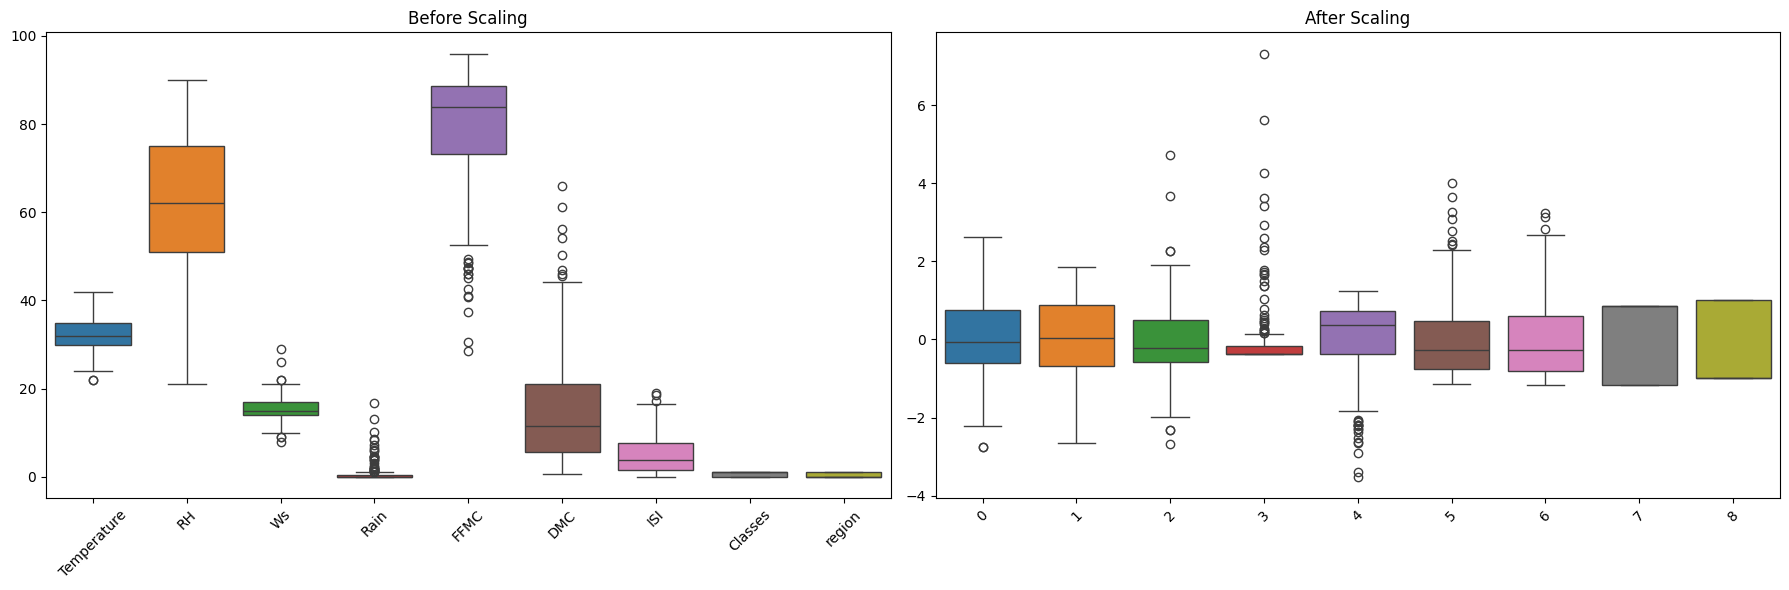

In [73]:
plt.figure(figsize=(18,6))

plt.subplot(1,2,1)
sns.boxplot(data=X_train)
plt.xticks(rotation=45, fontsize=10)
plt.title("Before Scaling")

plt.subplot(1,2,2)
sns.boxplot(data=X_train_scaled)
plt.xticks(rotation=45, fontsize=10)
plt.title("After Scaling")

plt.tight_layout()
plt.show()


## Linear Regression Model

r2 score: 0.9773899683550065
mean absolute error: 0.6700307048370664


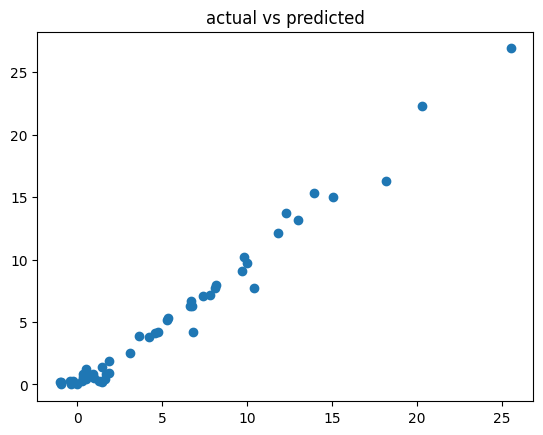

In [74]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
regressor = LinearRegression()
regressor.fit(X_train_scaled,Y_train)
y_pred = regressor.predict(X_test_scaled)
r2=r2_score(Y_test,y_pred)
mae = mean_absolute_error(Y_test,y_pred)
print("r2 score:",r2)
print("mean absolute error:",mae)
plt.scatter(y_pred,Y_test)
plt.title("actual vs predicted")

plt.show()

## Lasso Regression

r2 score: 0.9433416904087941
mean absolute error: 1.1144861330607516


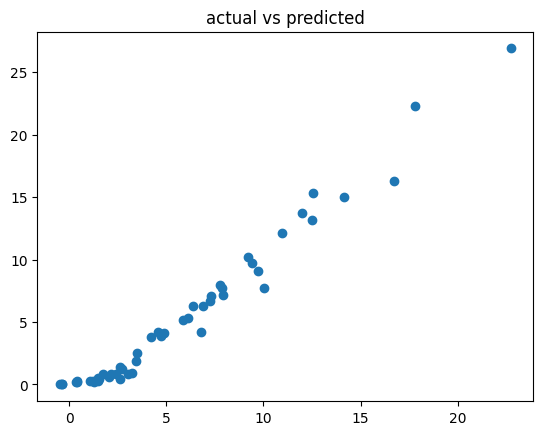

In [75]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error,r2_score
lasso = Lasso()
lasso.fit(X_train_scaled,Y_train)
y_pred = lasso.predict(X_test_scaled)
r2=r2_score(Y_test,y_pred)
mae = mean_absolute_error(Y_test,y_pred)
print("r2 score:",r2)
print("mean absolute error:",mae)
plt.scatter(y_pred,Y_test)
plt.title("actual vs predicted")
plt.show()


## cross validation with lasso

r2 score: 0.9774306736468266
mean absolute error: 0.6596236862193227


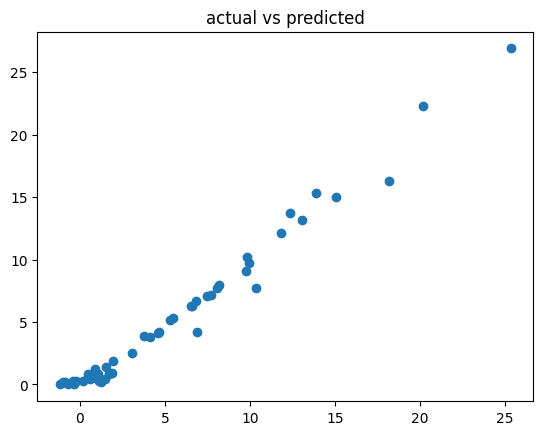

In [76]:
from sklearn.linear_model import LassoCV
lasso_cv = LassoCV(cv=5)
lasso_cv.fit(X_train_scaled,Y_train)
y_pred = lasso_cv.predict(X_test_scaled)
r2=r2_score(Y_test,y_pred)
mae = mean_absolute_error(Y_test,y_pred)
print("r2 score:",r2)
print("mean absolute error:",mae)
plt.scatter(y_pred,Y_test)
plt.title("actual vs predicted")
plt.show()

In [77]:
lasso_cv.alpha_

np.float64(0.0284206785480546)

In [78]:
lasso_cv.alphas_

array([7.04001909, 6.56554536, 6.12304958, 5.71037653, 5.32551626,
       4.96659429, 4.63186246, 4.31969043, 4.02855775, 3.75704644,
       3.50383409, 3.2676874 , 3.0474562 , 2.84206785, 2.65052199,
       2.47188568, 2.30528886, 2.14992011, 2.00502269, 1.86989087,
       1.74386648, 1.62633572, 1.51672613, 1.41450387, 1.31917104,
       1.23026333, 1.1473477 , 1.0700203 , 0.99790452, 0.93064909,
       0.86792646, 0.80943112, 0.75487817, 0.70400191, 0.65655454,
       0.61230496, 0.57103765, 0.53255163, 0.49665943, 0.46318625,
       0.43196904, 0.40285578, 0.37570464, 0.35038341, 0.32676874,
       0.30474562, 0.28420679, 0.2650522 , 0.24718857, 0.23052889,
       0.21499201, 0.20050227, 0.18698909, 0.17438665, 0.16263357,
       0.15167261, 0.14145039, 0.1319171 , 0.12302633, 0.11473477,
       0.10700203, 0.09979045, 0.09306491, 0.08679265, 0.08094311,
       0.07548782, 0.07040019, 0.06565545, 0.0612305 , 0.05710377,
       0.05325516, 0.04966594, 0.04631862, 0.0431969 , 0.04028

##  Ridge Regression

r2 score: 0.9766228010748004
mean absolute error: 0.6905345455834943


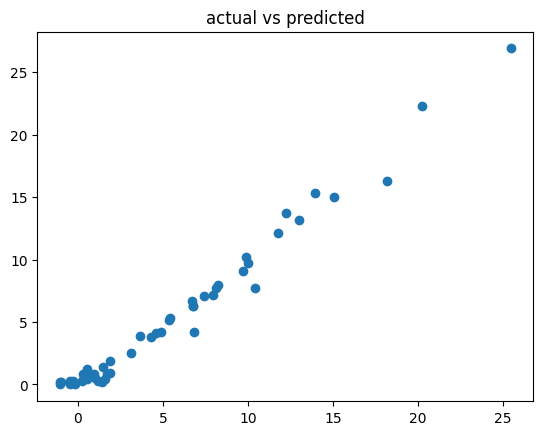

In [79]:
from sklearn.linear_model import Ridge
ridge = Ridge()
ridge.fit(X_train_scaled,Y_train)
y_pred = ridge.predict(X_test_scaled)
r2=r2_score(Y_test,y_pred)
mae = mean_absolute_error(Y_test,y_pred)
print("r2 score:",r2)
print("mean absolute error:",mae)
plt.scatter(y_pred,Y_test)
plt.title("actual vs predicted")
plt.show()

## Ridge cross validation

r2 score: 0.9677330008807272
mean absolute error: 0.8714379868451522


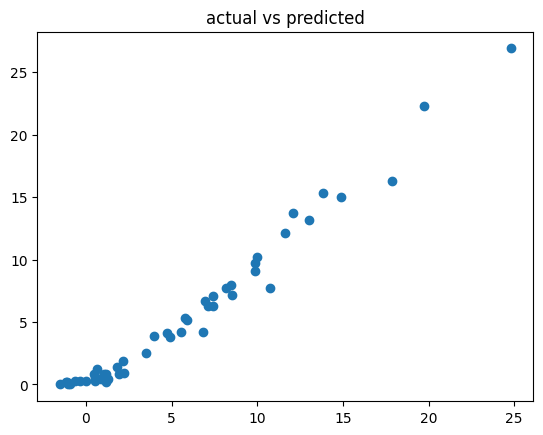

In [80]:
from sklearn.linear_model import RidgeCV
ridge_cv = RidgeCV(cv=5)
ridge_cv.fit(X_train_scaled,Y_train)
y_pred = ridge_cv.predict(X_test_scaled)
r2=r2_score(Y_test,y_pred)
mae = mean_absolute_error(Y_test,y_pred)
print("r2 score:",r2)
print("mean absolute error:",mae)
plt.scatter(y_pred,Y_test)
plt.title("actual vs predicted")
plt.show()

In [81]:
ridge_cv.get_params()

{'alpha_per_target': False,
 'alphas': (0.1, 1.0, 10.0),
 'cv': 5,
 'fit_intercept': True,
 'gcv_mode': None,
 'scoring': None,
 'store_cv_results': None,
 'store_cv_values': 'deprecated'}

## Elasticnet Regression

r2 score: 0.8777177823187075
mean absolute error: 1.7415526320622194


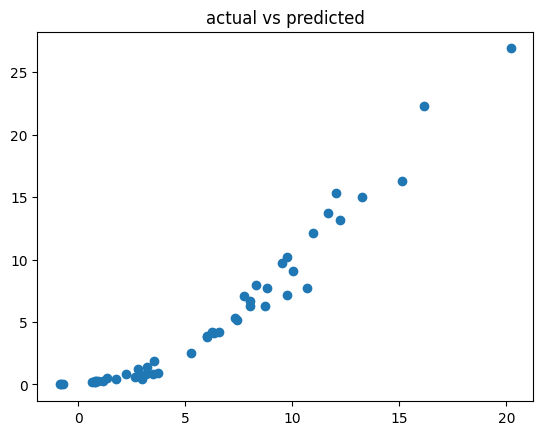

In [82]:
from sklearn.linear_model import ElasticNet
elasticnet = ElasticNet()
elasticnet.fit(X_train_scaled,Y_train)
y_pred = elasticnet.predict(X_test_scaled)
r2=r2_score(Y_test,y_pred)
mae = mean_absolute_error(Y_test,y_pred)
print("r2 score:",r2)
print("mean absolute error:",mae)
plt.scatter(y_pred,Y_test)
plt.title("actual vs predicted")
plt.show()

## Elastic CV

r2 score: 0.9734769909970736
mean absolute error: 0.7609068947918352


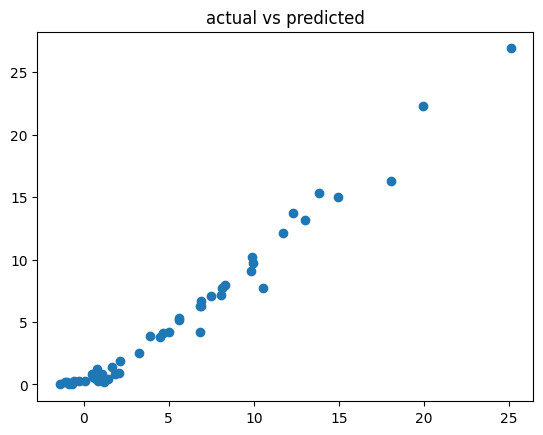

In [83]:
from sklearn.linear_model import ElasticNetCV
elasticnet_cv = ElasticNetCV(cv=5)
elasticnet_cv.fit(X_train_scaled,Y_train)
y_pred = elasticnet_cv.predict(X_test_scaled)
r2=r2_score(Y_test,y_pred)
mae = mean_absolute_error(Y_test,y_pred)
print("r2 score:",r2)
print("mean absolute error:",mae)
plt.scatter(y_pred,Y_test)
plt.title("actual vs predicted")
plt.show()

In [84]:
lasso_cv

LassoCV(cv=5)

In [85]:
scalar

StandardScaler()

In [87]:
import pickle
pickle.dump(scalar,open('scalar.pkl','wb'))
pickle.dump(lasso_cv,open('lasso_cv.pkl','wb'))